In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)
np.random.seed(29)

In [5]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6


In [6]:
len(df)

18000

In [7]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 13000, 1000):
    train_data = df.head(i)
    test_data = df.tail(5000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels\ag-20250203_045005"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       55.60 GB / 63.72 GB (87.3%)
Disk Space Avail:   1279.57 GB / 1906.98 GB (67.1%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\AutogluonModels\ag-20250203_045005"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid2', 'rpi-4a', 'odroid1', 'odroid4', 'rpi-8c', 'odroid3', 'rpi-8a', 'rpi-8d', 'rpi-8b']
	If 'multiclass' is not the correct problem_type, please manually specify th

[1000]	valid_set's multi_error: 0.1775


	0.8325	 = Validation score   (accuracy)
	16.47s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8525	 = Validation score   (accuracy)
	10.52s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8425	 = Validation score   (accuracy)
	0.48s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.83	 = Validation score   (accuracy)
	0.47s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.825	 = Validation score   (accuracy)
	2.12s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8325	 = Validation score   (accuracy)
	0.5s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	

[1000]	valid_set's multi_error: 0.128333


	0.8733	 = Validation score   (accuracy)
	27.91s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8917	 = Validation score   (accuracy)
	12.43s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8717	 = Validation score   (accuracy)
	0.61s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8683	 = Validation score   (accuracy)
	0.6s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.825	 = Validation score   (accuracy)
	2.12s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8633	 = Validation score   (accuracy)
	0.62s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: ExtraTreesEntr ...

...

	0.9114	 = Validation score   (accuracy)
	36.45s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8957	 = Validation score   (accuracy)
	0.6s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9029	 = Validation score   (accuracy)
	0.61s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8986	 = Validation score   (accuracy)
	3.58s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.91	 = Validation score   (accuracy)
	0.56s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.9029	 = Validation score   (accuracy)
	0.59s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: XGBoost ...
c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:02:19] WARNING:

[1000]	valid_set's multi_error: 0.105


	0.9012	 = Validation score   (accuracy)
	22.09s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9175	 = Validation score   (accuracy)
	11.12s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9062	 = Validation score   (accuracy)
	0.56s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.905	 = Validation score   (accuracy)
	0.58s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9025	 = Validation score   (accuracy)
	3.34s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8962	 = Validation score   (accuracy)
	0.51s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ..

[1000]	valid_set's multi_error: 0.110909


	0.8927	 = Validation score   (accuracy)
	59.55s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8982	 = Validation score   (accuracy)
	27.87s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8891	 = Validation score   (accuracy)
	0.68s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8845	 = Validation score   (accuracy)
	0.68s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8664	 = Validation score   (accuracy)
	2.34s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8845	 = Validation score   (accuracy)
	0.64s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: ExtraTreesEntr .

In [8]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.811439,0.8110,0.810297
1,2000,0.840790,0.8398,0.838838
2,3000,0.861316,0.8622,0.861158
3,4000,0.867770,0.8678,0.866786
4,5000,0.878440,0.8788,0.877699
5,6000,0.878788,0.8796,0.878759
6,7000,0.884221,0.8850,0.883941
7,8000,0.884000,0.8850,0.884051
8,9000,0.889340,0.8902,0.889257
9,10000,0.889776,0.8906,0.889591


<Axes: xlabel='data_amount', ylabel='value'>

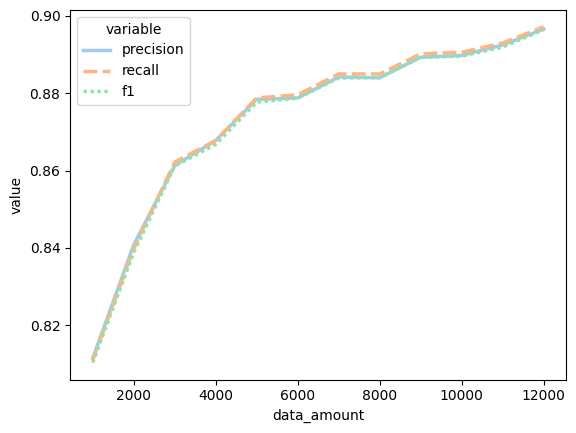

In [9]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [10]:
best_model

{'RandomForestEntr': 4,
 'RandomForestGini': 5,
 'LightGBM': 9,
 'ExtraTreesGini': 1,
 'ExtraTreesEntr': 1,
 'LightGBMLarge': 7,
 'WeightedEnsemble_L2': 9}

([<matplotlib.patches.Wedge at 0x189458f1d10>,
 [Text(1.0336618818860421, 0.3762221603465248, 'RandomForestEntr'),
  Text(0.46488006198695686, 0.9969385778306522, 'RandomForestGini'),
  Text(-0.7778174957174646, 0.7778174228929385, 'LightGBM'),
  Text(-1.0958141633505245, -0.09587136903367023, 'ExtraTreesGini'),
  Text(-1.062518395034835, -0.28470100142535226, 'ExtraTreesEntr'),
  Text(-0.6309340260869244, -0.9010672864585332, 'LightGBMLarge'),
  Text(0.7778175139235951, -0.7778174046868057, 'WeightedEnsemble_L2')],
 [Text(0.563815571937841, 0.20521208746174077, '11%'),
  Text(0.25357094290197646, 0.5437846788167193, '14%'),
  Text(-0.42426408857316245, 0.4242640488506937, '25%'),
  Text(-0.5977168163730133, -0.05229347401836557, '3%'),
  Text(-0.579555488200819, -0.15529145532291938, '3%'),
  Text(-0.3441458324110496, -0.49149124715919984, '19%'),
  Text(0.4242640985037791, -0.4242640389200758, '25%')])

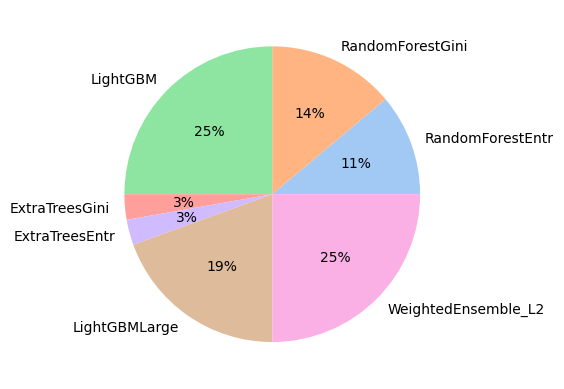

In [11]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [12]:
best_features

{'Feature 1': 11, 'Feature 2': 12, 'Feature 3': 9, 'Feature 6': 4}

([<matplotlib.patches.Wedge at 0x1894ee92050>,
 [Text(0.630934089359929, 0.9010672421543008, 'Feature 1'),
  Text(-1.0832885303005317, 0.19101298416420232, 'Feature 2'),
  Text(0.09587136262132409, -1.0958141639115324, 'Feature 3'),
  Text(1.0336618994982714, -0.3762221119573192, 'Feature 6')],
 [Text(0.3441458669235976, 0.49149122299325493, '31%'),
  Text(-0.5908846528911991, 0.10418890045320126, '33%'),
  Text(0.052293470520722224, -0.5977168166790177, '25%'),
  Text(0.5638155815445116, -0.20521206106762865, '11%')])

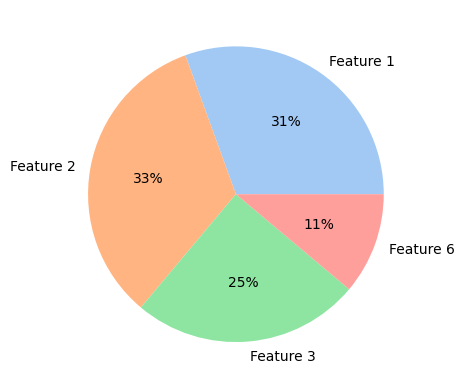

In [13]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [14]:
feature_importance

,importance,stddev,p_value,n,p99_high,p99_low
Feature 2,0.16476,0.003700,3.049033e-08,5,0.172378,0.157142
Feature 1,0.10040,0.004350,4.216990e-07,5,0.109356,0.091444
Feature 3,0.09912,0.003042,1.062826e-07,5,0.105383,0.092857
Feature 0,0.06504,0.001857,7.963827e-08,5,0.068863,0.061217
Feature 4,0.06464,0.003451,9.709682e-07,5,0.071745,0.057535
Feature 6,0.05920,0.003611,1.653096e-06,5,0.066635,0.051765
Feature 5,0.04856,0.002351,6.574252e-07,5,0.053401,0.043719


In [15]:
# train_data = df.head(10000)
# test_data = df.tail(8000)

# predictor = TabularPredictor(label='label', eval_metric='log_loss').fit(train_data, num_gpus=1, presets='good_quality', time_limit=3600)
# y_pred = predictor.predict(test_data)
# y_pred_proba = predictor.predict_proba(test_data)
# results = predictor.evaluate(test_data, detailed_report=True)

No path specified. Models will be saved in: "AutogluonModels\ag-20250203_052434"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       50.50 GB / 63.72 GB (79.3%)
Disk Space Avail:   1266.43 GB / 1906.98 GB (66.4%)
Presets specified: ['good_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DyStack is enabled (dynamic_stacking=True). AutoGluo

(_ray_fit pid=25656) [1000]	valid_set's multi_logloss: 0.339262


(_dystack pid=20228) 	-0.3597	 = Validation score   (-log_loss)
(_dystack pid=20228) 	5.62s	 = Training   runtime
(_dystack pid=20228) 	0.71s	 = Validation runtime
(_dystack pid=20228) Fitting model: LightGBM_BAG_L1 ... Training model for up to 576.08s of the 873.87s of remaining time.
(_dystack pid=20228) Specified total num_gpus: 1, but only 0 are available. Will use 0 instead
(_dystack pid=20228) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=4, gpus=0, memory=0.01%)
(_dystack pid=20228) 	-0.3098	 = Validation score   (-log_loss)
(_dystack pid=20228) 	2.66s	 = Training   runtime
(_dystack pid=20228) 	0.1s	 = Validation runtime
(_dystack pid=20228) Fitting model: RandomForestGini_BAG_L1 ... Training model for up to 571.30s of the 869.09s of remaining time.
(_dystack pid=20228) Specified total num_gpus: 1, but only 0 are available. Will use 0 instead
(_dystack pid=20228) 	-0.3414	 = Validation score   (-log_loss)
(_dystack p

KeyboardInterrupt: 

In [15]:
results

{'log_loss': -0.25845703413057214,
 'accuracy': 0.89675,
 'balanced_accuracy': 0.8968594077435816,
 'mcc': 0.883877043783628,
 'confusion_matrix':          odroid1  odroid2  odroid3  odroid4  rpi-4a  rpi-8a  rpi-8b  rpi-8c  \
 odroid1      875        0       30        0       0       0       0       1   
 odroid2        3      878        4        1       0       0       0       0   
 odroid3       33        3      872        7       0       0       0       0   
 odroid4        0        0        3      877       0       0       0       0   
 rpi-4a         0        0        0        0     774       0       7      40   
 rpi-8a         0        0        0        0       0     802      81       1   
 rpi-8b         0        0        0        0       0      81     786       1   
 rpi-8c         0        0        0        0      50       2      13     659   
 rpi-8d         0        0        0        0      71       4       6     179   
 
          rpi-8d  
 odroid1       0  
 odroid2      

In [16]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,-0.272940,log_loss,3.319105,539.439822,0.002110,1.089705,3,False,24
1,ExtraTreesGini_BAG_L2,-0.281500,log_loss,2.354031,304.802197,0.183459,0.354598,2,False,19
2,CatBoost_BAG_L2,-0.283061,log_loss,2.215236,447.045259,0.044664,142.597660,2,False,18
3,ExtraTreesEntr_BAG_L2,-0.285668,log_loss,2.359912,304.794546,0.189339,0.346946,2,False,20
4,LightGBMXT_BAG_L2,-0.286337,log_loss,2.270508,309.710770,0.099935,5.263170,2,False,14
5,NeuralNetFastAI_BAG_L2,-0.288554,log_loss,2.234527,325.076605,0.063955,20.629005,2,False,13
6,RandomForestGini_BAG_L2,-0.290923,log_loss,2.364797,305.148226,0.194225,0.700626,2,False,16
7,WeightedEnsemble_L2,-0.291806,log_loss,0.590137,106.313195,0.002069,0.581562,2,False,12
8,NeuralNetTorch_BAG_L2,-0.294208,log_loss,2.531995,368.365319,0.361423,63.917719,2,False,22
9,RandomForestEntr_BAG_L2,-0.298120,log_loss,2.374221,305.241019,0.203648,0.793419,2,False,17


In [17]:
# will return the path to the cloned predictor, identical to save_path_clone_opt
path_clone_opt = predictor.clone_for_deployment(path='classification')

Cloned TabularPredictor located in 'AutogluonModels/ag-20241101_073412' to 'classification'.
	To load the cloned predictor: predictor_clone = TabularPredictor.load(path="classification")
Clone: Keeping minimum set of models required to predict with best model 'WeightedEnsemble_L3_FULL'...
Deleting model NeuralNetFastAI_BAG_L1. All files under classification/models/NeuralNetFastAI_BAG_L1 will be removed.
Deleting model LightGBMXT_BAG_L1. All files under classification/models/LightGBMXT_BAG_L1 will be removed.
Deleting model LightGBM_BAG_L1. All files under classification/models/LightGBM_BAG_L1 will be removed.
Deleting model RandomForestGini_BAG_L1. All files under classification/models/RandomForestGini_BAG_L1 will be removed.
Deleting model RandomForestEntr_BAG_L1. All files under classification/models/RandomForestEntr_BAG_L1 will be removed.
Deleting model CatBoost_BAG_L1. All files under classification/models/CatBoost_BAG_L1 will be removed.
Deleting model ExtraTreesGini_BAG_L1. All 

In [18]:
predictor_clone_opt = TabularPredictor.load(path='classification')

In [19]:
predictor_clone_opt.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3_FULL,-0.258457,None,log_loss,0.903575,NaN,67.188084,0.004008,NaN,1.089705,3,True,19
1,LightGBMXT_BAG_L2_FULL,-0.262074,None,log_loss,0.535472,NaN,46.454468,0.018963,NaN,1.000624,2,True,13
2,CatBoost_BAG_L2_FULL,-0.262842,None,log_loss,0.524208,NaN,57.944929,0.007699,NaN,12.491084,2,True,15
3,ExtraTreesEntr_BAG_L2_FULL,-0.264218,None,log_loss,0.577846,NaN,45.800790,0.061337,0.189339,0.346946,2,True,17
4,ExtraTreesGini_BAG_L2_FULL,-0.266163,None,log_loss,0.576131,NaN,45.808442,0.059623,0.183459,0.354598,2,True,16
5,RandomForestEntr_BAG_L2_FULL,-0.271369,None,log_loss,0.575103,NaN,46.247263,0.058594,0.203648,0.793419,2,True,14
6,NeuralNetFastAI_BAG_L2_FULL,-0.276025,None,log_loss,0.565535,NaN,47.808657,0.049026,NaN,2.354813,2,True,12
7,NeuralNetTorch_BAG_L2_FULL,-0.280046,None,log_loss,0.644324,NaN,48.756895,0.127815,NaN,3.303051,2,True,18
8,LightGBM_BAG_L1_FULL,-0.281368,None,log_loss,0.022446,NaN,0.947886,0.022446,NaN,0.947886,1,True,3
9,XGBoost_BAG_L1_FULL,-0.286866,None,log_loss,0.029741,NaN,0.817327,0.029741,NaN,0.817327,1,True,9


In [20]:
size_original = predictor.disk_usage()
size_opt = predictor_clone_opt.disk_usage()
print(f'Size Original:  {size_original} bytes')
print(f'Size Optimized: {size_opt} bytes')
print(f'Optimized predictor achieved a {round((1 - (size_opt/size_original)) * 100, 1)}% reduction in disk usage.')

Size Original:  910871344 bytes
Size Optimized: 427523098 bytes
Optimized predictor achieved a 53.1% reduction in disk usage.


*** SIGTERM received at time=1730452320 on cpu 9 ***
PC: @     0x77d8e232a042  (unknown)  epoll_wait
    @     0x77d8e2245320  (unknown)  (unknown)
    @     0x77d8e2903c52  (unknown)  select_epoll_poll_impl
[2024-11-01 20:12:00,674 E 1466 1466] logging.cc:361: *** SIGTERM received at time=1730452320 on cpu 9 ***
[2024-11-01 20:12:00,674 E 1466 1466] logging.cc:361: PC: @     0x77d8e232a042  (unknown)  epoll_wait
[2024-11-01 20:12:00,675 E 1466 1466] logging.cc:361:     @     0x77d8e2245320  (unknown)  (unknown)
[2024-11-01 20:12:00,675 E 1466 1466] logging.cc:361:     @     0x77d8e2903c52  (unknown)  select_epoll_poll_impl
